# Experiments with new optimiser
------

## Imports

In [277]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from tqdm import tqdm
from importlib import reload
reload(func)

<module 'functions' from 'C:\\Users\\Mahfuzah Fariha\\OneDrive - The University of Nottingham\\Documents\\Year 4\\Research Project\\Code\\plots\\higher_costs\\functions.py'>

## Constants

In [278]:
N = 2 ** 20
N_16 = 2 ** 16
p = 1-e**-2 # our table coverage

## Numerical Optimisation

In [279]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor):   # add v_cost if want vanilla cost to be set beforehand
    # t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    t = 200
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    # first 10 columns have a lower bound of 5 then 1 after that
    # bound = Bounds([5 if i < 2 else 1 for i in range(t)], [float("inf") for i in range(t)])
    bound = Bounds([20 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1e-3})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Test lower cost bounds with new optimiser

In [280]:
# first do 1.125 1.25 and 1.5 for N = 2^16 like we did for N = 2^20

def test_cost_factors_around_1(N, p, alphas, factors):
    
    # for each factor
    for factor in tqdm(factors, desc="Processing factors"):
        # place to store all the kj's for the factor
        results = []
        
        # for each alpha
        for alpha in tqdm(alphas, desc="Processing alphas"):
            K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
            # plot_kjs_cost(N, K_js, m_0, alpha, factor)
            results.append([K_js, m_0, final_cost, m_values])
            
        # store all kj's for the factor in a .pickle file
        with open(f"N_16/around_1/{factor}P(V)/factor_{factor}_5_column_lowerbound_10.pickle", "wb") as f:
            pickle.dump(results, f)
        
        # plot all alpha kjs on the same graph
        func.plot_all_alpha(results, N_16, factor)
        

In [281]:
# run all the factors around 1

# factors = [1.5, 1.25, 1.125]
# alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# test_cost_factors_around_1(N_16, p, alphas, factors)

## Compare change in endpoints with different lower bounds

In [282]:
# for lower bounds : 1 , 3, 5
# have two plots : one for change in endpoints and one for change in cost
# one set of graphs for each cost 

def compare_endpoints(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the endpoints for each alpha
        endpoints = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            endpoints.append(res[3][-1])
        
        # plot the endpoints
        ax.plot(endpoints, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Number of endpoints", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in endpoints for different lower bounds for " + factor)
    plt.show()
    

In [283]:
# now similar function to compare change in largest Kj cherry picked from
def compare_kj(factor, alphas, bounds, results_list):
    # get figure ready
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # for each factor
    for i in range(len(bounds)):
        # extract the KJ for each alpha
        kj = []
        
        # get the results for the factor
        results = results_list[i]
        
        # loop through each alpha in results and get the last m value
        for res in results:
            kj.append(max(res[0]))
        
        # plot the endpoints
        ax.plot(kj, label=f"lower bound = {bounds[i]}")
        
    # add the legend
    ax.legend()
    
    # add axis labels
    ax.set_ylabel("Largest Kj", **{"fontsize": 12, "labelpad": -2})
    ax.set_xlabel("alpha", **{"fontsize": 12})
    ax.set_xticklabels(alphas)
        
    # add title
    fig.suptitle("Difference in largest Kj for different lower bounds for " + factor)
    plt.show()

In [284]:
# store bounds 1 3 5
# results_list = []
# 
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_1_new_tol.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_3.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# with open("N_16/around_1/1.5P(V)/factor_1.5_new_op_lower_bound_5.pickle", "rb") as f:
#     results_list.append(pickle.load(f))
#     
# bounds = [1, 3, 5]
# alphas = [0, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
# factor = "1.5P(V) - P(C) < 0"
# 
# compare_endpoints(factor, alphas, bounds, results_list)
# compare_kj(factor, alphas, bounds, results_list)


## Test higher costs with new optimiser and bounds

In [285]:
def test_cost_factors(N, p, alpha):
    results = []
    factor = 5
    
    for i in range(20):
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
        results.append([K_js, m_0, final_cost, m_values])
        # increment factor by 5
        factor += 5
        
    return results

In [286]:
def test_all_alpha(N, p):
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    # store results 
    results = []
    
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    
    for alpha in tqdm(alphas, desc="Processing alphas"):
        res = test_cost_factors(N, p, alpha)
        results.append(res)
        
        # now plot them all on the same graph
        # get the title
        func.plot_all_kj(N, res, cost_factors, legend_label, alpha)
        
    return results

In [287]:
def plot_all_results(all_results, N):
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    func.plot_all(N, all_results, cost_factors, legend_label, alphas)

Processing alphas:   0%|          | 0/8 [00:00<?, ?it/s]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1353.1094659115035
            Iterations: 17
            Function evaluations: 3428
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1419.4723941588934
            Iterations: 18
            Function evaluations: 3619
            Gradient evaluations: 18
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1453.3577517929198
            Iterations: 21
            Function evaluations: 4232
            Gradient evaluations: 21
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1476.106726015088
            Iterations: 22
            Function evaluations: 4445
            Gradient evaluations: 22
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1493.2299304289018
            Iterations: 21
            

Processing alphas:  12%|█▎        | 1/8 [01:47<12:33, 107.63s/it]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1592.741127498174
            Iterations: 26
            Function evaluations: 5247
            Gradient evaluations: 26
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1377.3765918552228
            Iterations: 16
            Function evaluations: 3217
            Gradient evaluations: 16
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1442.6883004513845
            Iterations: 18
            Function evaluations: 3619
            Gradient evaluations: 18
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1476.133915250076
            Iterations: 20
            Function evaluations: 4030
            Gradient evaluations: 20
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1498.6107478507474
            Iterations: 19
            F

Processing alphas:  25%|██▌       | 2/8 [03:11<09:23, 93.90s/it] 

...

Processing alphas:  75%|███████▌  | 6/8 [08:53<02:54, 87.03s/it]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1675.7061522110519
            Iterations: 27
            Function evaluations: 5448
            Gradient evaluations: 27
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1467.3871026032891
            Iterations: 17
            Function evaluations: 3418
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1528.351568967903
            Iterations: 19
            Function evaluations: 3820
            Gradient evaluations: 19
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1559.955538501208
            Iterations: 20
            Function evaluations: 4020
            Gradient evaluations: 20
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1581.3026881907513
            Iterations: 22
            F

Processing alphas:  88%|████████▊ | 7/8 [12:57<02:18, 138.15s/it]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1490.5219977448398
            Iterations: 17
            Function evaluations: 3417
            Gradient evaluations: 17
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1550.2732910063778
            Iterations: 19
            Function evaluations: 3819
            Gradient evaluations: 19
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1581.3719841650268
            Iterations: 20
            Function evaluations: 4021
            Gradient evaluations: 20
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1602.410607683262
            Iterations: 22
            Function evaluations: 4428
            Gradient evaluations: 22
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1618.282702198515
            Iterations: 25
            F

Processing alphas: 100%|██████████| 8/8 [17:37<00:00, 132.24s/it]


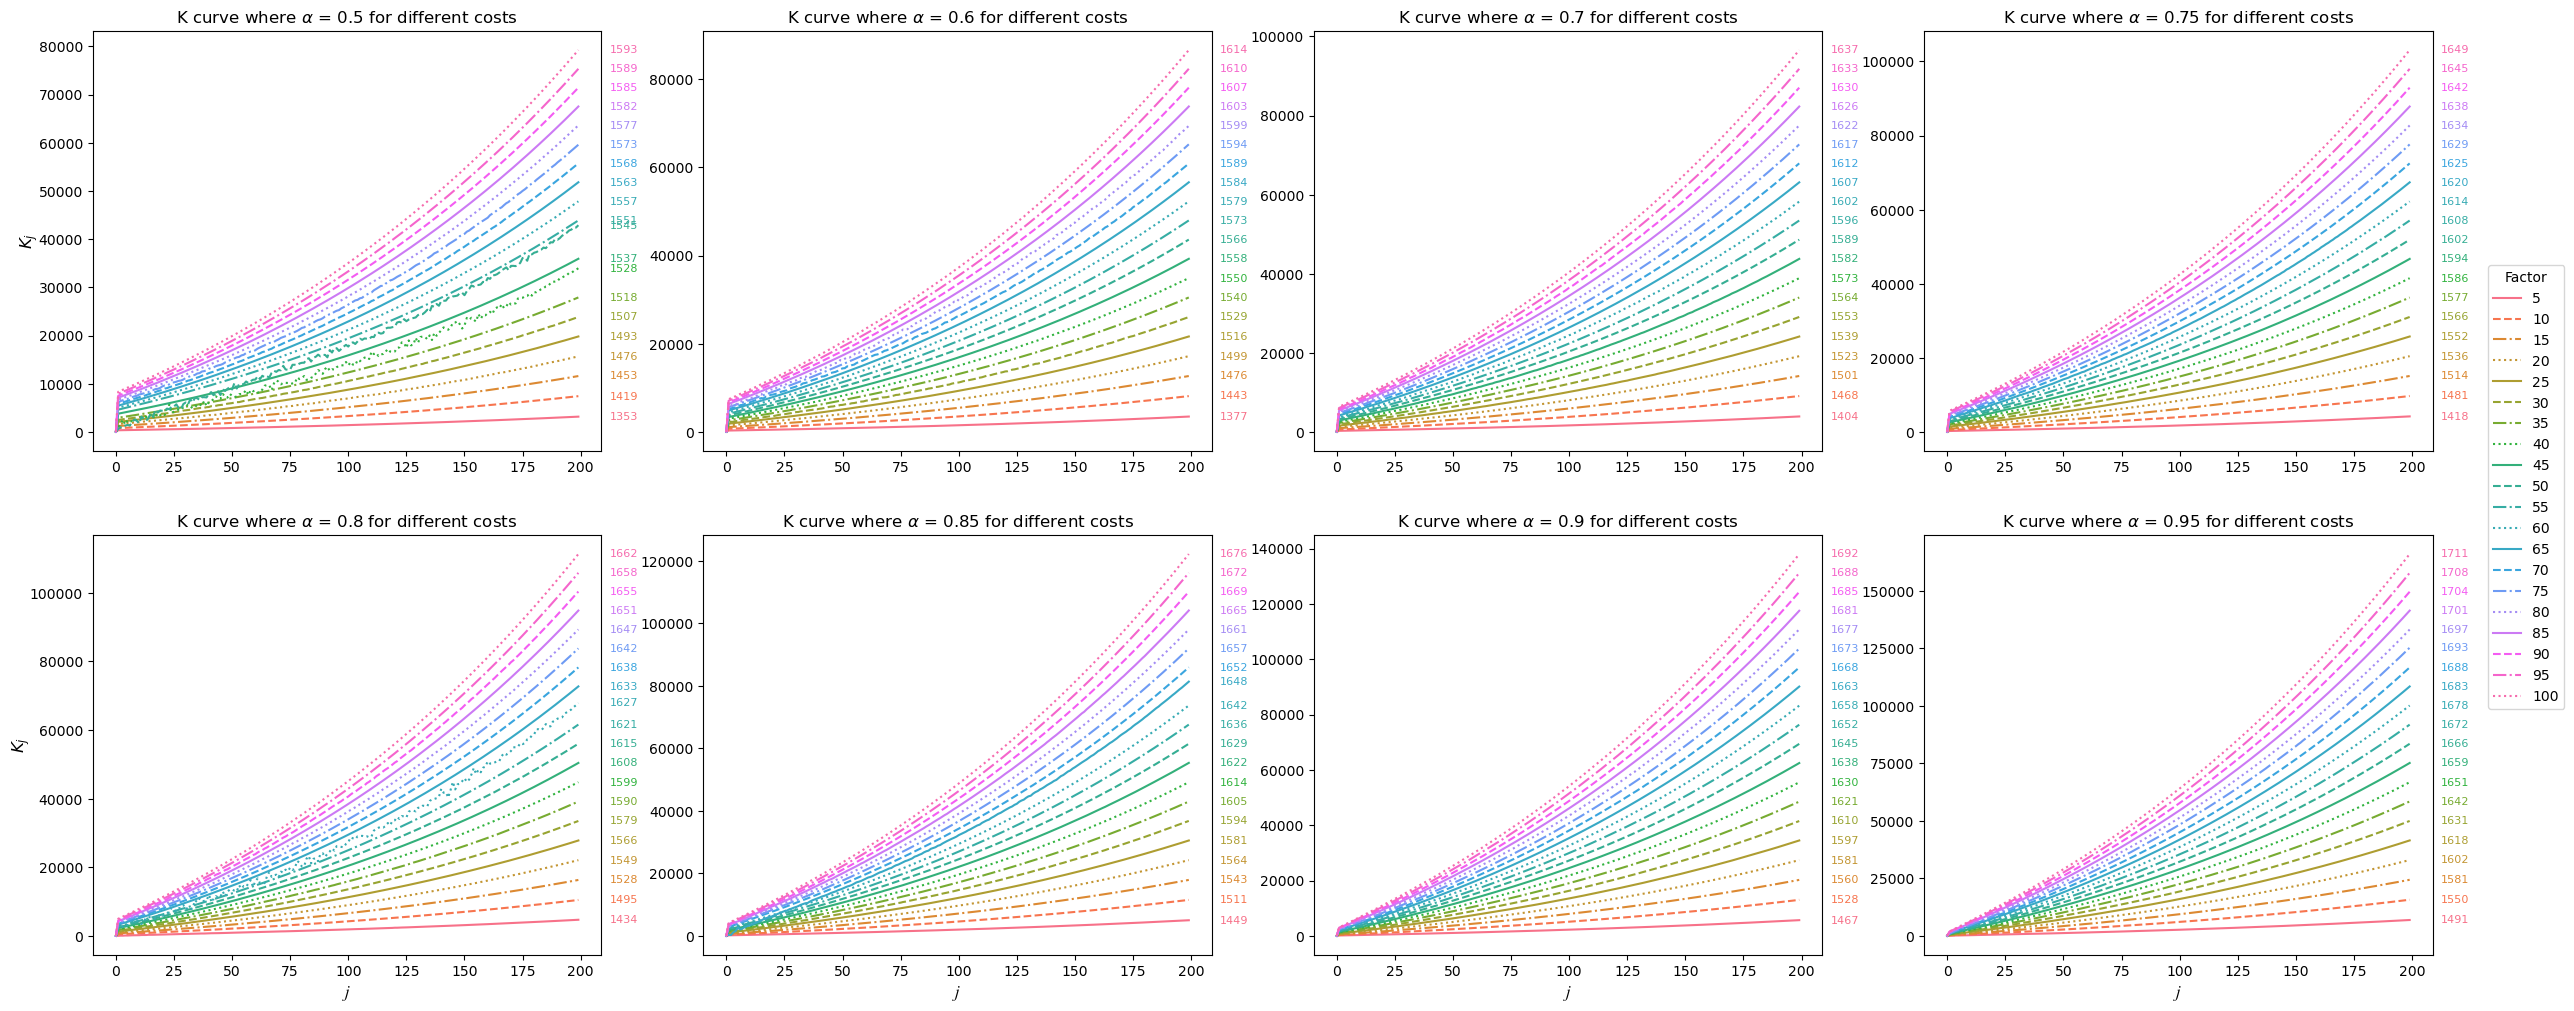

In [288]:
# now run the function
results = test_all_alpha(N_16, p)

# store the results in a pickle file
with open("N_16/higher_costs_all_column_lowerbound_20_t_200.pickle", "wb") as f:
    pickle.dump(results, f)

# plot on one graph
plot_all_results(results, N_16) 